In [1]:
import os
import subprocess
import logging
import sys

def source_lmod_script(script_path):
    """
    Source an Lmod/module script and import environment variables into Python safely,
    suppressing terminal warnings.
    """
    # Use a non-interactive login shell (bash -l), redirect errors
    command = f'bash -l -c "source {script_path} >/dev/null 2>&1; printenv -0"'
    
    proc = subprocess.Popen(command, stdout=subprocess.PIPE, shell=True)
    out, _ = proc.communicate()
    
    # Parse null-separated environment variables
    for env_var in out.split(b'\0'):
        if env_var:
            key, _, value = env_var.partition(b'=')
            os.environ[key.decode()] = value.decode()

# Example usage
M3_BUILD_DIR = "/home/henryi/scratch/venvs/.venv_sbi/bin/"
TUTORIAL_BUILD_DIR = M3_BUILD_DIR
source_lmod_script(f"{M3_BUILD_DIR}/setup.MaCh3.sh")
source_lmod_script(f"{TUTORIAL_BUILD_DIR}/setup.MaCh3Tutorial.sh")
os.environ["OMP_NUM_THREADS"] = "8"


my_stderr = sys.stderr = open('errors.txt', 'w')  # redirect stderr to file
get_ipython().log.handlers[0].stream = my_stderr  # log errors to new stderr
get_ipython().log.setLevel(logging.INFO)  # errors are logged at info level

cat: write error: Broken pipe
cat: write error: Broken pipe


In [2]:
from mach3sbitools.inference.sbi_interface import MaCh3SBIInterface
from mach3sbitools.mach3_interface.mach3_simulator import MaCh3Simulator
from mach3sbitools.utils.logger import MaCh3Logger, get_logger
from mach3sbitools.utils.config import TrainingConfig, PosteriorConfig
from mach3sbitools.utils.device_handler import TorchDeviceHandler

from sbi.analysis.plot import sbc_rank_plot
from sbi.diagnostics import check_sbc, check_tarp, run_sbc, run_tarp
from sbi.analysis import pairplot

import itertools
import pickle as pkl
from pathlib import Path

import uproot as ur
import numpy as np
from scipy.stats import gaussian_kde

from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from tqdm.notebook import tqdm

from getdist import MCSamples
import getdist.plots as gdplt

from rich.table import Table
from rich.console import Console

import torch

logger = get_logger("mach3sbitools")
log_level='INFO'
log_file=None
MaCh3Logger("mach3sbitools", level=log_level, log_file=log_file)

device_handler = TorchDeviceHandler()

In [3]:
inference = MaCh3SBIInterface("Tutorial", Path("/home/henryi/sft/MaCh3Tutorial/TutorialConfigs/FitterConfig.yaml"),
                              cyclical_pars=['delta_cp'])

[Monitor.cpp][info] ##################################
[Monitor.cpp][info] Welcome to:  
[Monitor.cpp][info]   __  __        _____ _     ____  
[Monitor.cpp][info]  |  \/  |      / ____| |   |___ \ 
[Monitor.cpp][info]  | \  / | __ _| |    | |__   __) |
[Monitor.cpp][info]  | |\/| |/ _` | |    | '_ \ |__ < 
[Monitor.cpp][info]  | |  | | (_| | |____| | | |___) |
[Monitor.cpp][info]  |_|  |_|\__,_|\_____|_| |_|____/ 
[Monitor.cpp][info] Version: 2.3.1
[Monitor.cpp][info] ##################################
[Monitor.cpp][info] Using following CPU:
[Monitor.cpp][info] model name	: AMD EPYC 9454 48-Core Processor
[Monitor.cpp][info] cpu MHz		: 2750.000
[Monitor.cpp][info] Architecture:                         x86_64
[Monitor.cpp][info] L1d cache:                            1.5 MiB (48 instances)
[Monitor.cpp][info] L1i cache:                            1.5 MiB (48 instances)
[Monitor.cpp][info] L2 cache:                             48 MiB (48 instances)
[Monitor.cpp][info] L3 cache:         

In [4]:
# model_path = Path(f"/home/henryi/scratch/TutorialSBI/analyses/10M_256Hid_15Tr_MAF_lr1e-4/models/256hid_20tr.ts")
model_path=Path("/home/henryi/scratch/TutorialSBI/analyses/10M_350Hid_20Tr_MAF_lr1e-5_BS1024/models/256hid_20tr.ts")
posterior_config = PosteriorConfig(
    hidden_features = 350,      # was 50 — scale up to match data volume
    num_transforms= 20,         # was 10 — fewer needed with NSF, less sequential overhead
    dropout_probability= 0.1,  # fine as-is, good regularisation for 5M samples  
    num_blocks= 2,             # fine as-is
    # NSF-specific
    # num_bins= 10,             
    # spline bins, 8-12 is the usual sweet spot
)

inference.load_posterior(model_path, posterior_config)
samples = inference.sample_posterior(500000).cpu()

2026-03-02 02:39:53 INFO     Loading autosave checkpoint from epoch 1020

                    INFO     NPE created | maf | hidden=350 transforms=20 blocks=2 bins=10

                    INFO     Density estimator loaded from                                                         
                             /home/henryi/scratch/TutorialSBI/analyses/10M_350Hid_20Tr_MAF_lr1e-5_BS1024/models/256
                             hid_20tr.ts

                    INFO     Sampling 500,000 points from posterior

  0%|          | 0/500000 [00:00<?, ?it/s]

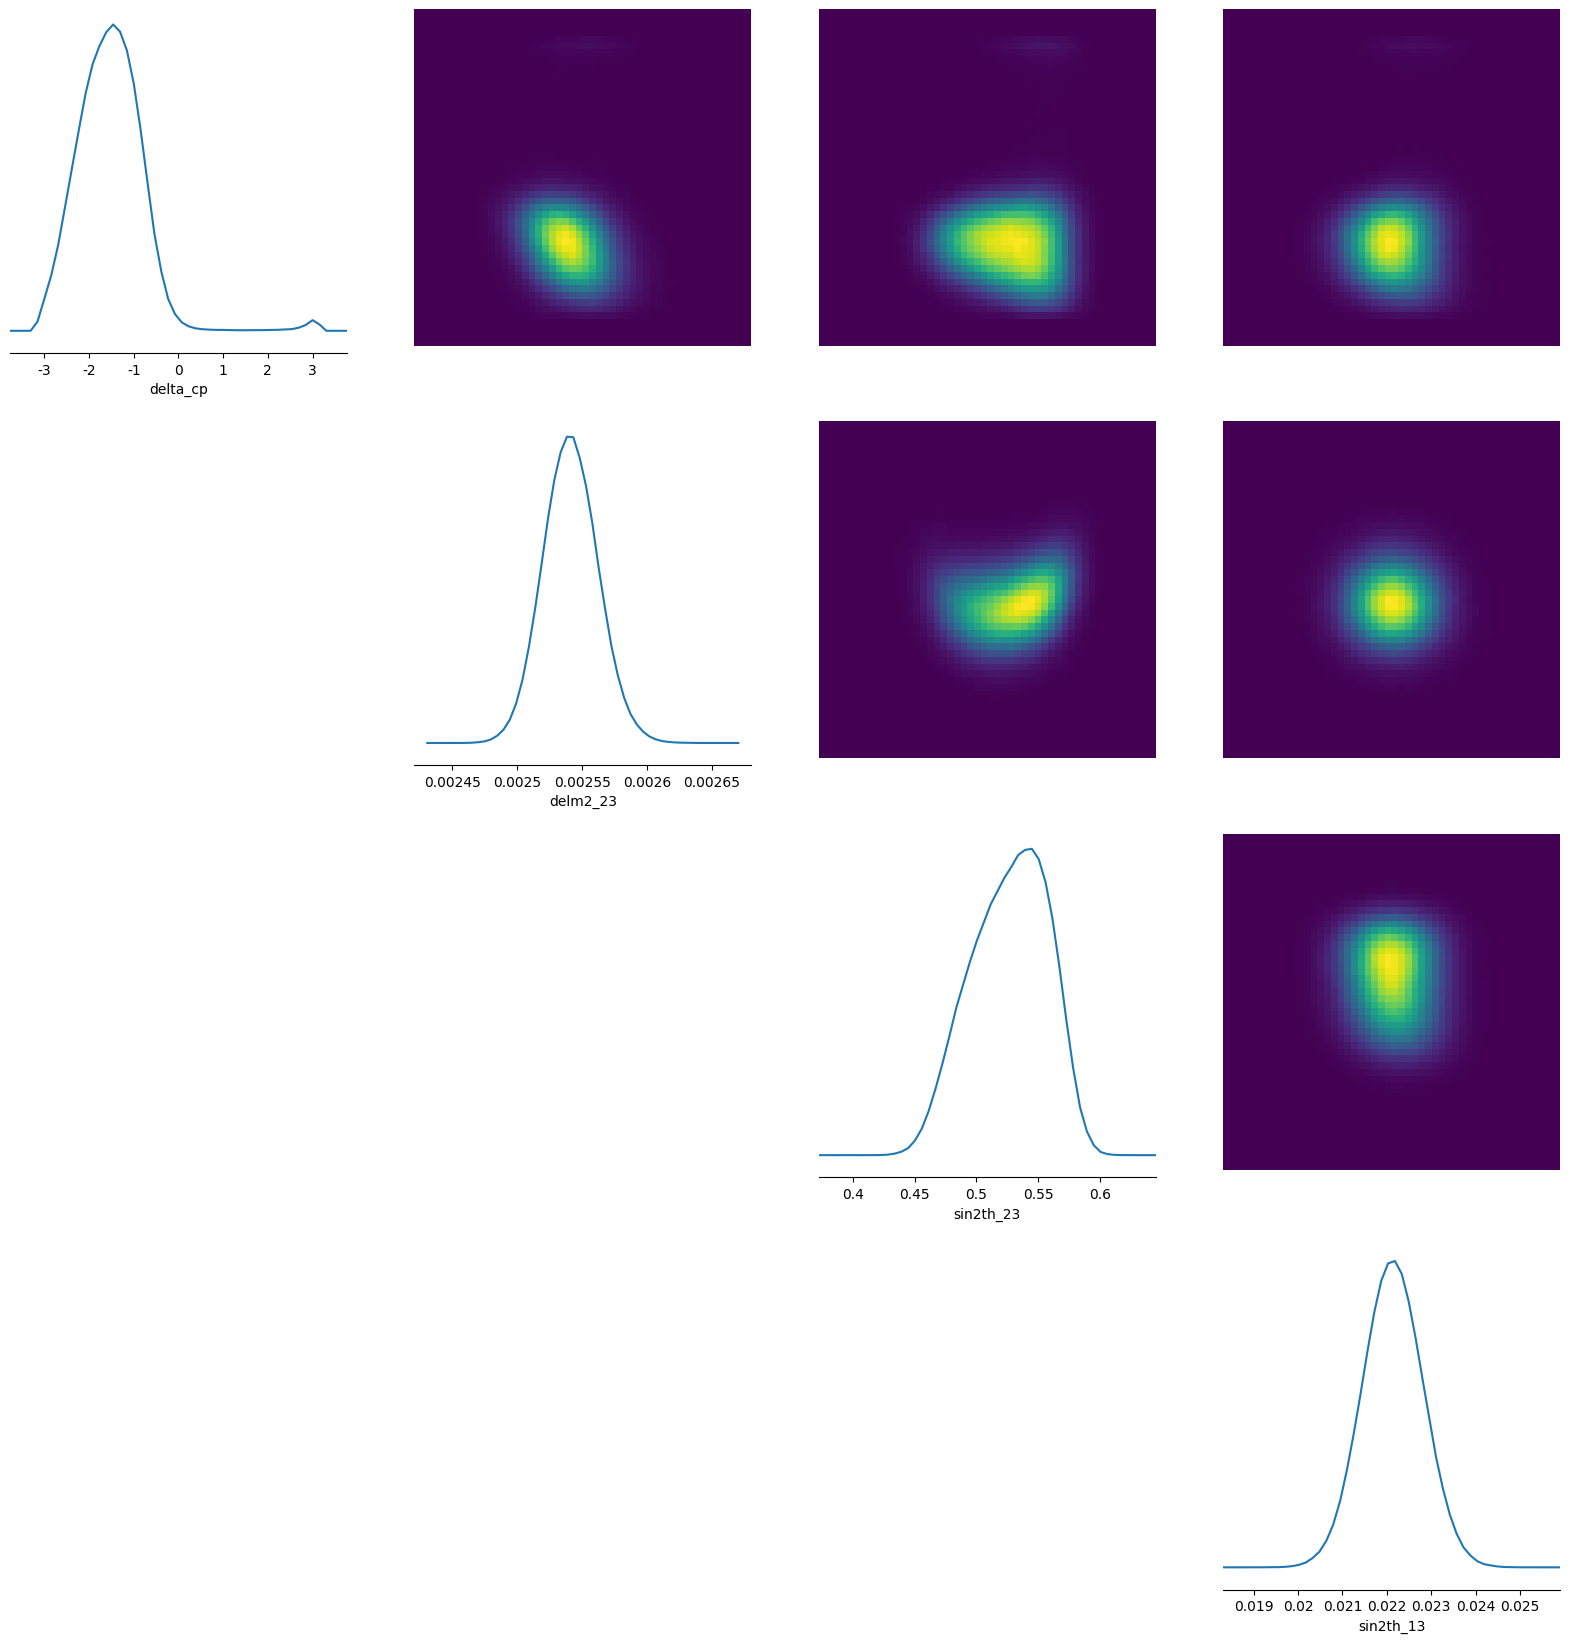

In [9]:
xo = device_handler.to_tensor(inference.simulator.mach3_wrapper.get_data_bins())
inference.posterior.set_default_x(xo)

pp_check=['delta_cp', 'delm2_23', 'sin2th_23', 'sin2th_13']

names = inference.simulator.mach3_wrapper.get_parameter_names()
sample_indices = [names.index(i) for i in pp_check]
sample_indices = device_handler.to_tensor(sample_indices).cpu()

subsample = samples[:, sample_indices]
subsample[:, 0]= (subsample[:, 0] + np.pi) % (2 * np.pi) - np.pi

pairplot(subsample,
    upper=["kde"],
    diag=["kde"],
    figsize=(20, 20),
    labels=pp_check,
)

plt.show()

In [11]:
simulator = inference.simulator.mach3_wrapper
mach3_sims = []
for t in tqdm(samples.numpy()):
    x = simulator.simulate(t)
    mach3_sims.append(np.random.poisson(x))

  0%|          | 0/500000 [00:00<?, ?it/s]

ValueError: Maximum allowed size exceeded

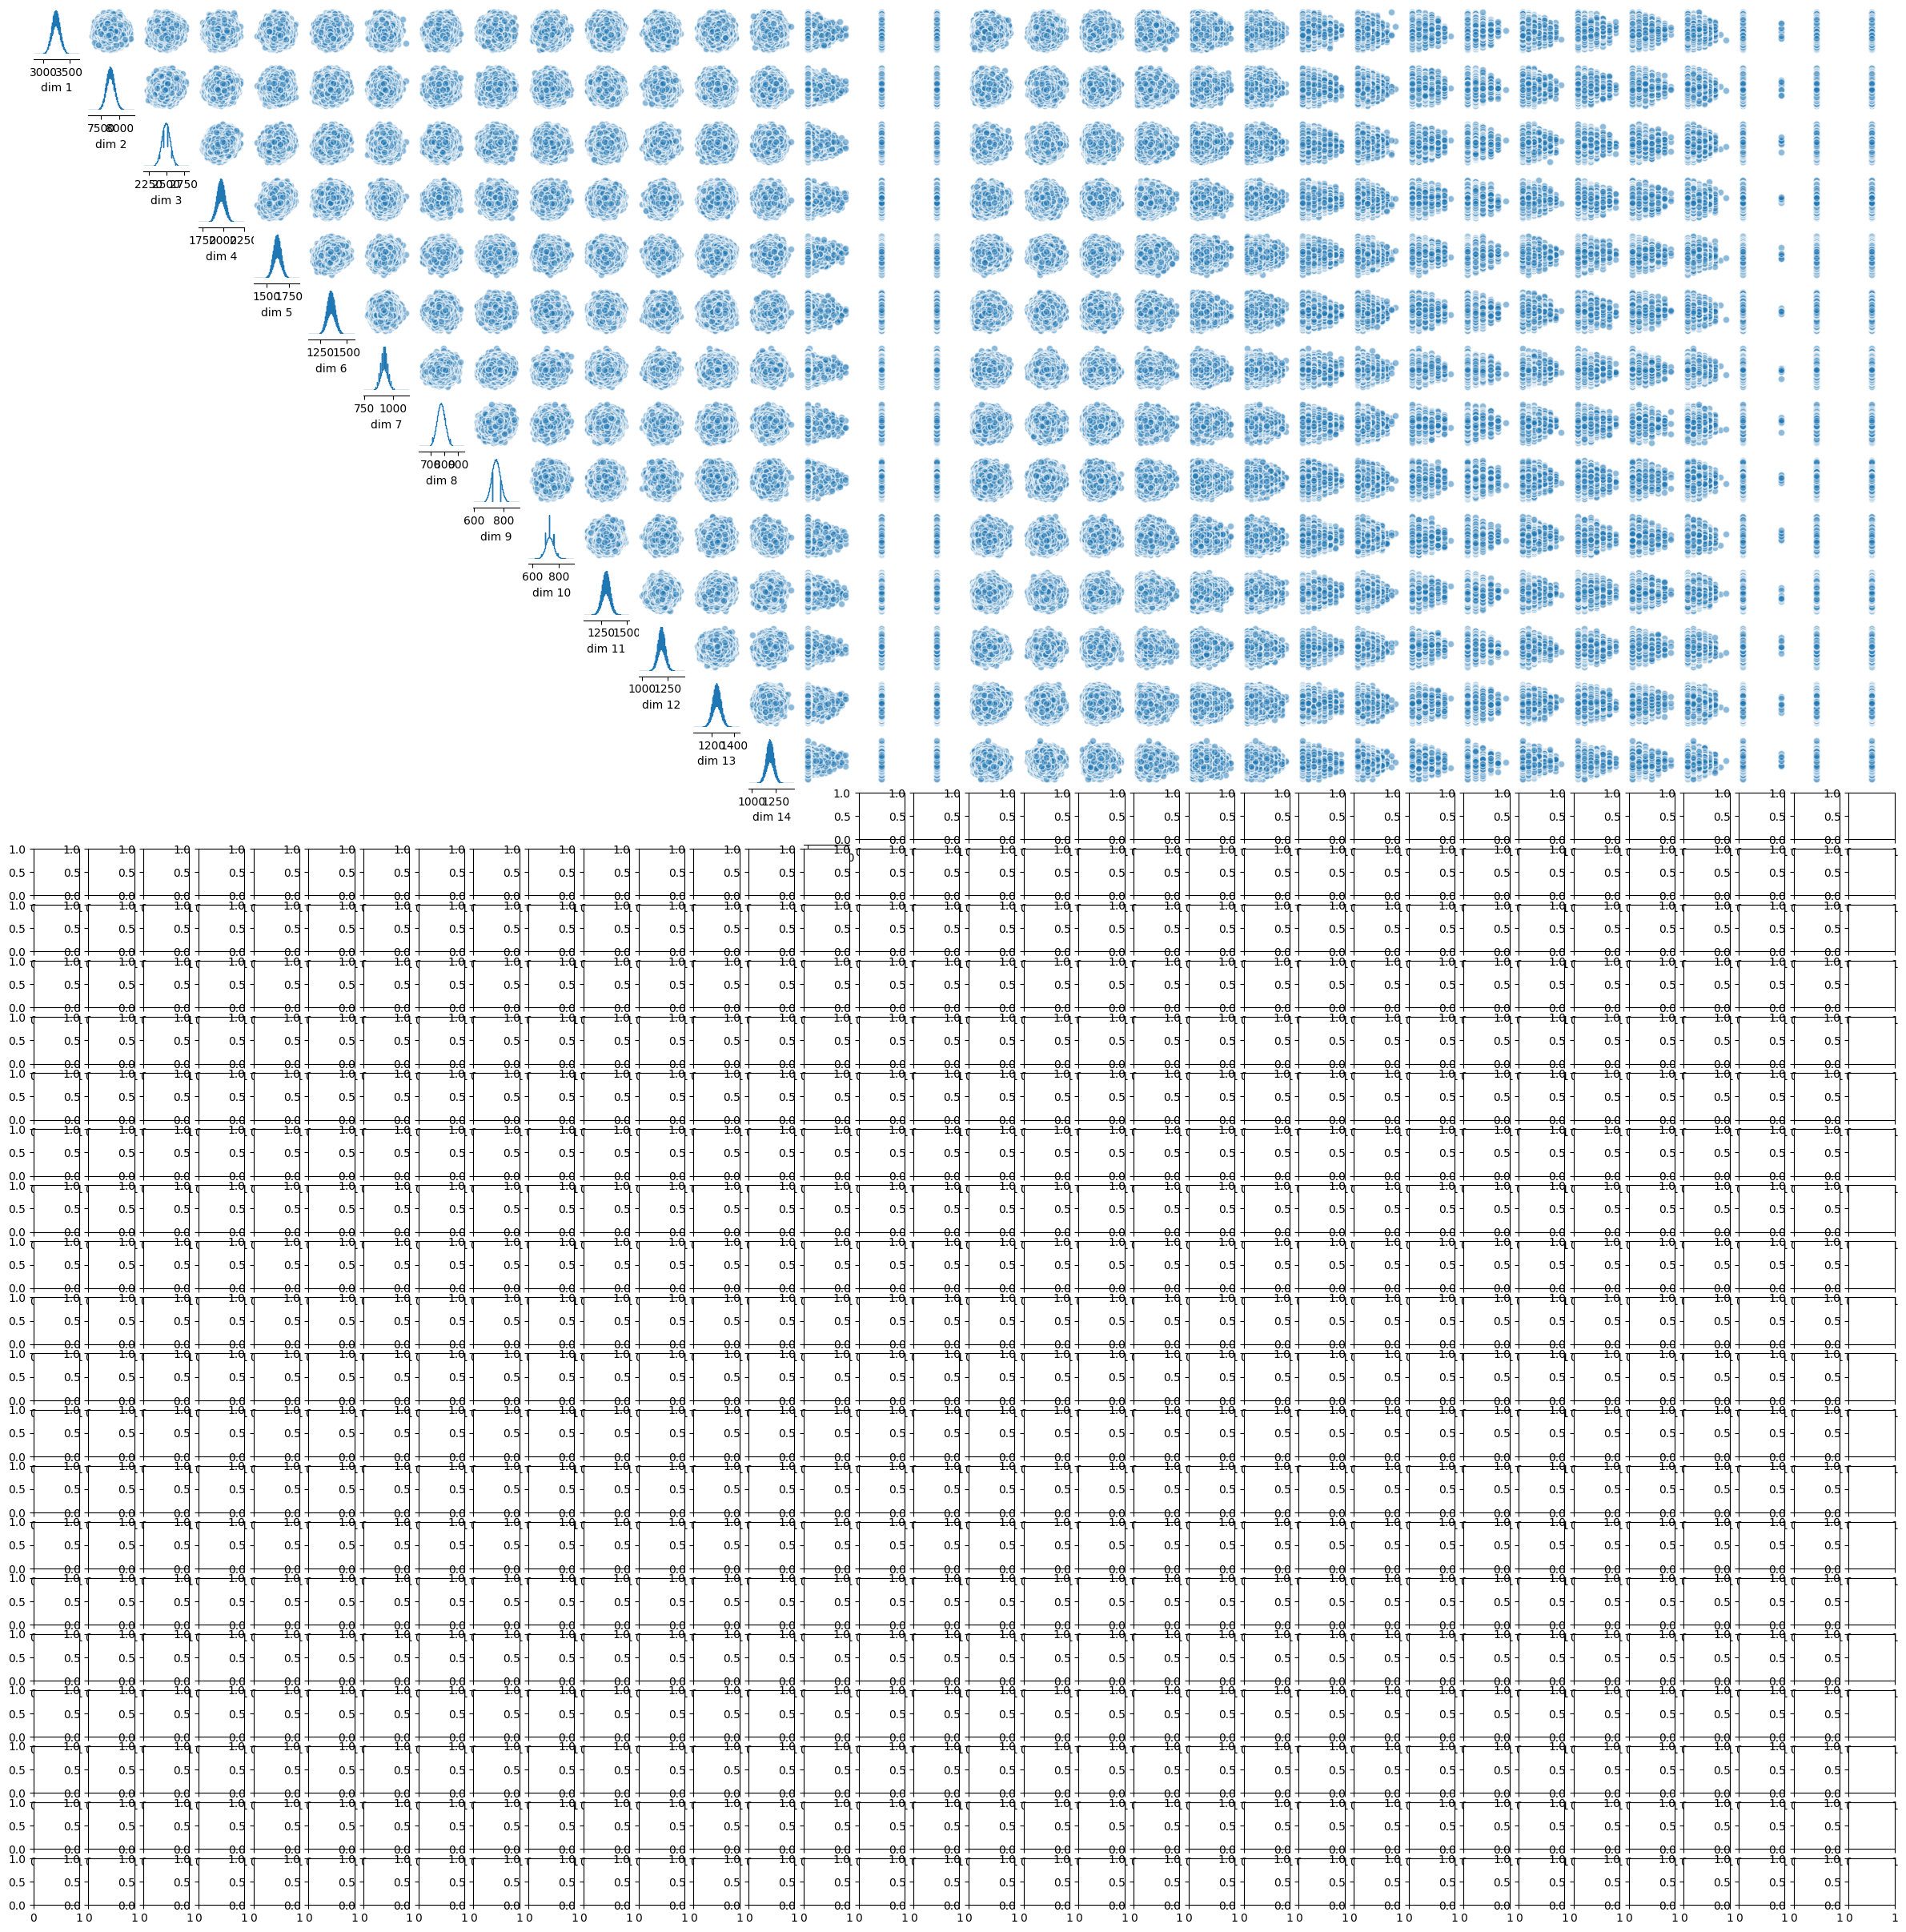